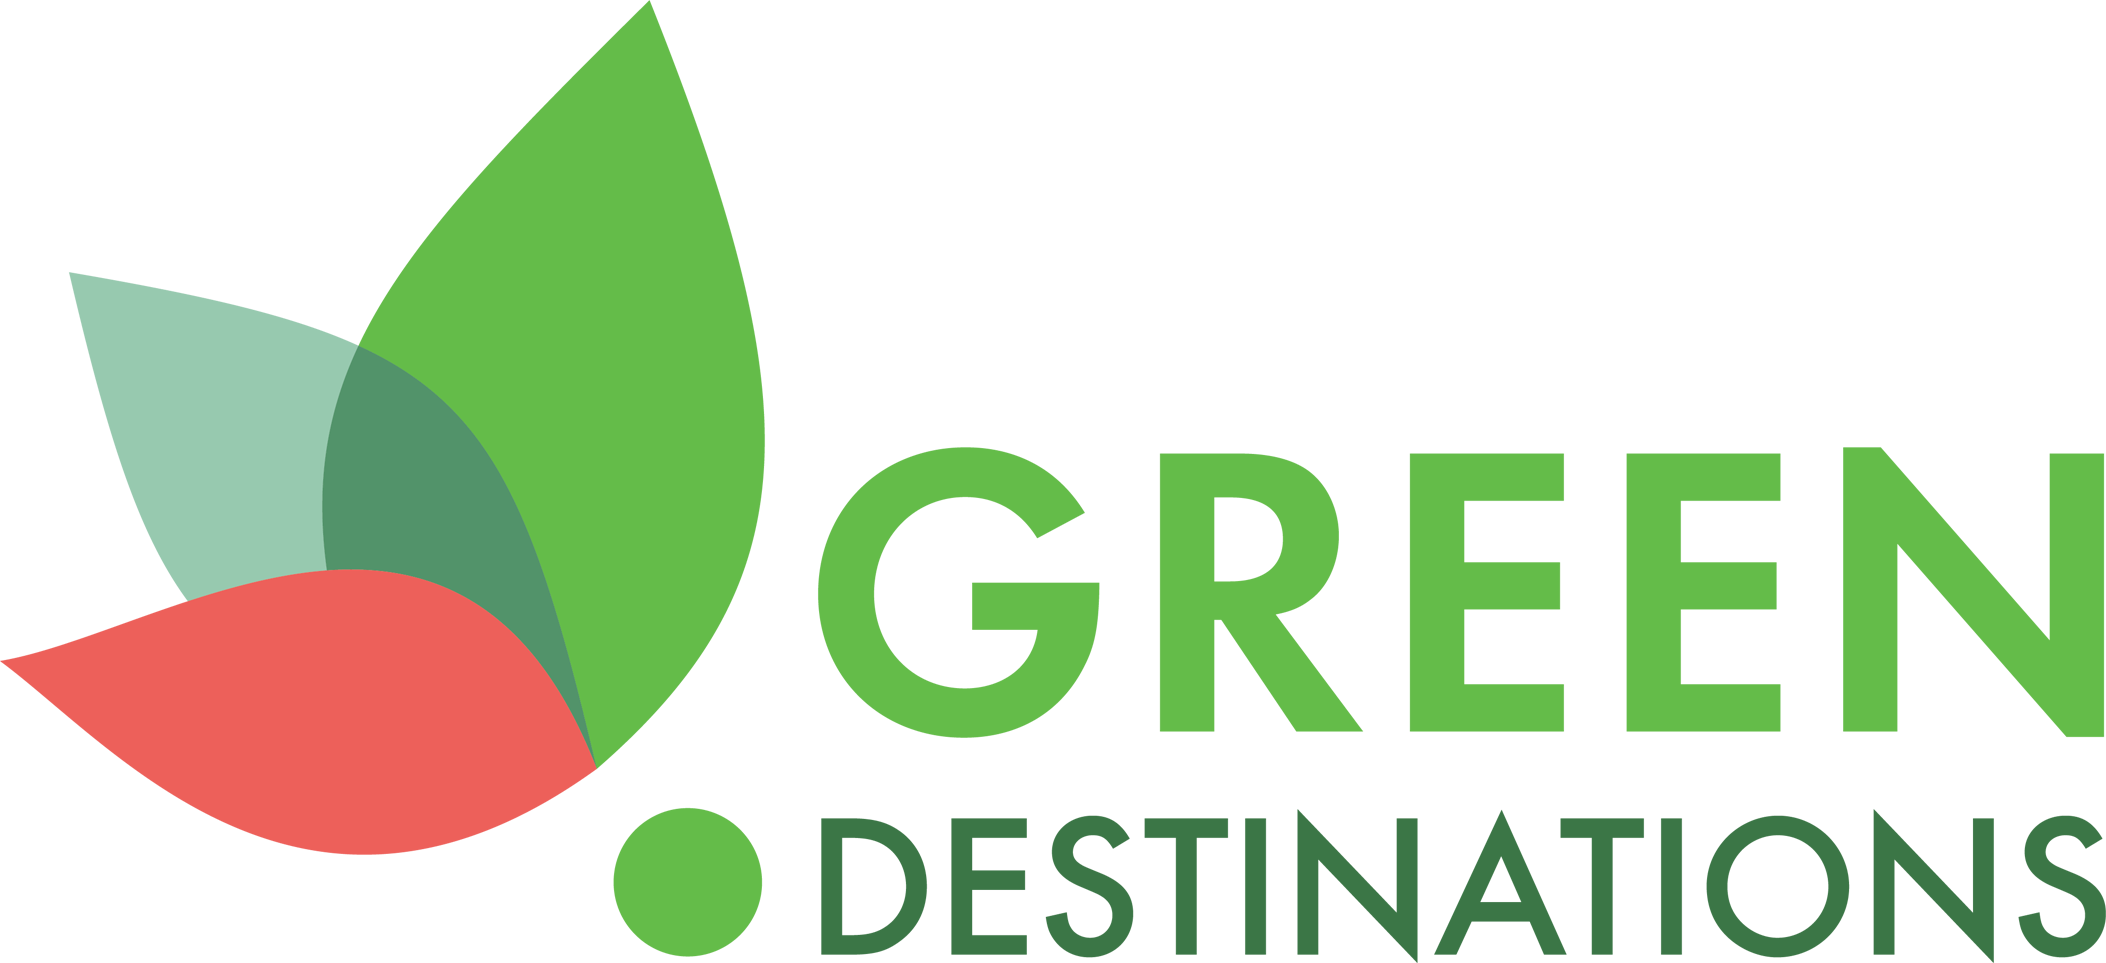

"This project analyzes employee attrition using data analytics and explores whether factors such as age, years at company, and monthly income influence attrition."

In [15]:
# Importing dataset and checking Null Values.

import pandas as pd
data = pd.read_csv("/content/greendestination (1).csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [4]:
# Calculating Attrition Rate.

attrition_rate = (data['Attrition'].value_counts(normalize = True)['Yes'])*100
print(f"Attrition Rate: {attrition_rate:.2f}%")

Attrition Rate: 16.12%


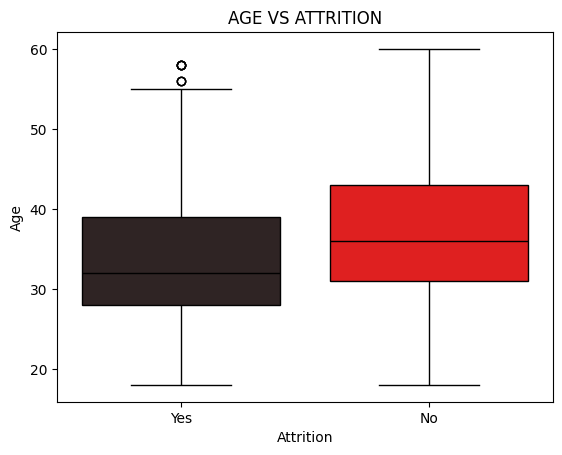

In [16]:
# Checking the factors like (Age, Years at Company, and Income) are affecting the attrition or not.

import matplotlib.pyplot as plt
import seaborn as sns

# Checking the factor 'Age'.

sns.boxplot(x = 'Attrition', y = 'Age', data = data, palette = 'dark:red', linecolor = 'k', hue = 'Attrition')
plt.title('AGE VS ATTRITION')
plt.show()

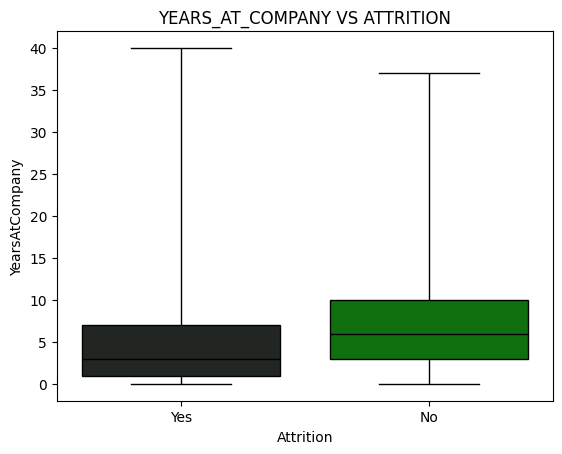

In [17]:
# Checking the factor 'Years at the company'.

sns.boxplot(x = 'Attrition', y = 'YearsAtCompany', data = data, whis = (0,100), palette = 'dark:g', linecolor = 'k', hue = 'Attrition')
plt.title('YEARS_AT_COMPANY VS ATTRITION')
plt.show()

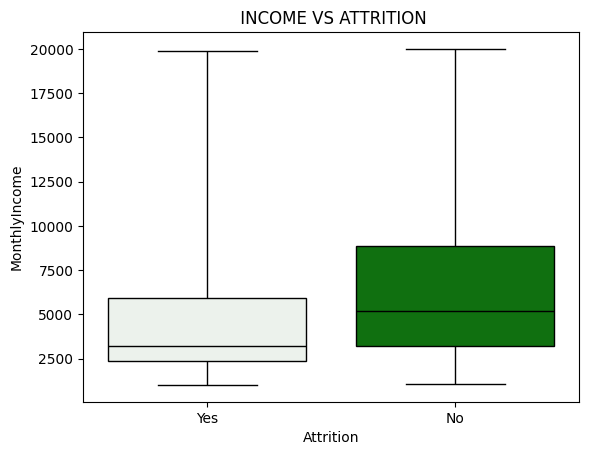

In [18]:
# Checking the factor 'Income'.

sns.boxplot(x = 'Attrition', y = 'MonthlyIncome', data = data, palette = 'light:g', linecolor = 'k', hue = 'Attrition', whis = (0, 100))
plt.title(' INCOME VS ATTRITION')
plt.show()

In [8]:
# For Statistical Summary of Attrition

print(data.groupby('Attrition')[['Age']].describe())
print(data.groupby('Attrition')[['YearsAtCompany']].describe())
print(data.groupby('Attrition')[['MonthlyIncome']].describe())


              Age                                                  
            count       mean      std   min   25%   50%   75%   max
Attrition                                                          
No         1233.0  37.561233  8.88836  18.0  31.0  36.0  43.0  60.0
Yes         237.0  33.607595  9.68935  18.0  28.0  32.0  39.0  58.0
          YearsAtCompany                                               
                   count      mean       std  min  25%  50%   75%   max
Attrition                                                              
No                1233.0  7.369019  6.096298  0.0  3.0  6.0  10.0  37.0
Yes                237.0  5.130802  5.949984  0.0  1.0  3.0   7.0  40.0
          MonthlyIncome                                                    \
                  count         mean          std     min     25%     50%   
Attrition                                                                   
No               1233.0  6832.739659  4818.208001  1051.0  3211.0  52

In [9]:
print(data.groupby('Attrition')[['Age', 'YearsAtCompany', 'MonthlyIncome']].mean())

                 Age  YearsAtCompany  MonthlyIncome
Attrition                                          
No         37.561233        7.369019    6832.739659
Yes        33.607595        5.130802    4787.092827


In [10]:
# Total employees
total_employees = data.shape[0]

# Attrition counts
attrition_counts = data['Attrition'].value_counts()
employees_left = attrition_counts.get('Yes', 0)
employees_stayed = attrition_counts.get('No', 0)

# Attrition rate calculation
attrition_rate = (employees_left / total_employees) * 100

# Grouped summary
summary = data.groupby('Attrition')[['Age', 'YearsAtCompany']].mean().round(2)

# Display all together
print("📊 ATTRITION SUMMARY REPORT")
print(f"🔸 Total Employees: {total_employees}")
print(f"🔸 Employees Who Leave: {employees_left}")
print(f"🔸 Employees Who Stayed: {employees_stayed}")
print(f"🔸 Attrition Rate: {attrition_rate:.2f}%")
print("\n🔍 Average Age & Years at Company:")
print(summary)



📊 ATTRITION SUMMARY REPORT
🔸 Total Employees: 1470
🔸 Employees Who Leave: 237
🔸 Employees Who Stayed: 1233
🔸 Attrition Rate: 16.12%

🔍 Average Age & Years at Company:
             Age  YearsAtCompany
Attrition                       
No         37.56            7.37
Yes        33.61            5.13


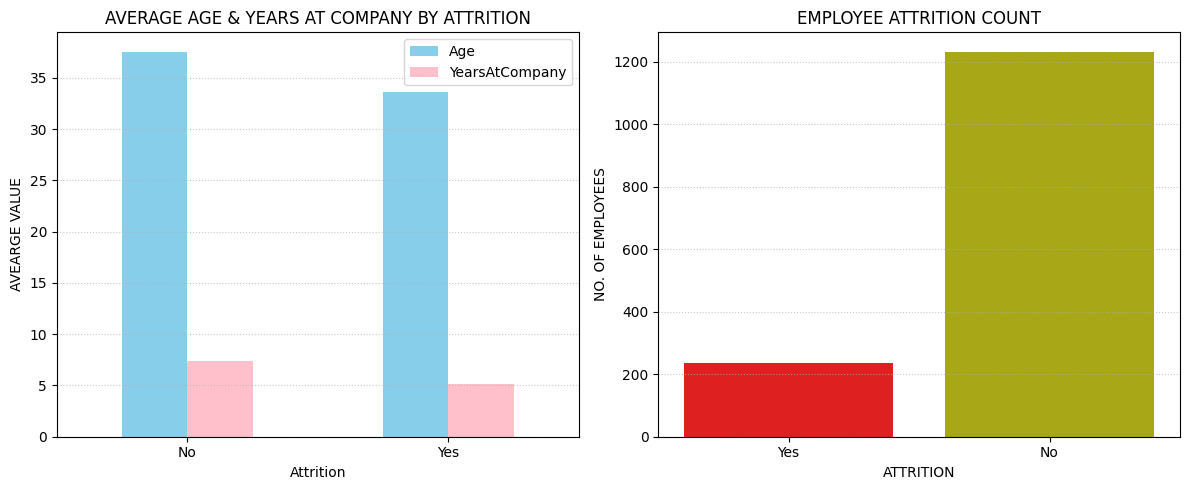

In [14]:
# Create a bar plot for number of employees
plt.figure(figsize=(12, 5))

# 1. Countplot
plt.subplot(1, 2, 2)
sns.countplot(x='Attrition', data=data, palette={'Yes': 'r', 'No': 'y'}, hue = 'Attrition', legend = False)
plt.title('EMPLOYEE ATTRITION COUNT')
plt.xlabel('ATTRITION')
plt.ylabel('NO. OF EMPLOYEES')
plt.grid(axis='y', linestyle=':', alpha=0.7)

# 2. Average Age & Years Plot
plt.subplot(1, 2, 1)
summary.plot(kind='bar', ax=plt.gca(), color=['skyblue', 'pink'])
plt.title('AVERAGE AGE & YEARS AT COMPANY BY ATTRITION')
plt.ylabel('AVEARGE VALUE')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

# 📌 Conclusion

This analysis shows that employee attrition at Green Destinations is 16.12%. Employees who leave tend to be younger, have shorter tenure, and earn lower monthly income compared to those who stay. These findings can help organizations identify at-risk employees and improve retention strategies.

🔸 Total Employees: 1470
🔸 Employees Who Left: 237
🔸 Employees Who Stayed: 1233
🔸 Attrition Rate: 16.12%

Avearge Age & Years at Compnay:

### Attrition

Age: Yes = 33.61, No = 37.56

YearsAtCompany: Yes = 5.13, No = 7.37


